Load packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import sympy as sp
from scipy.optimize import root
from sympy import symbols, diff
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.colors import ListedColormap, Normalize
import matplotlib as mpl
from matplotlib.lines import Line2D

# Supplementary figure 3

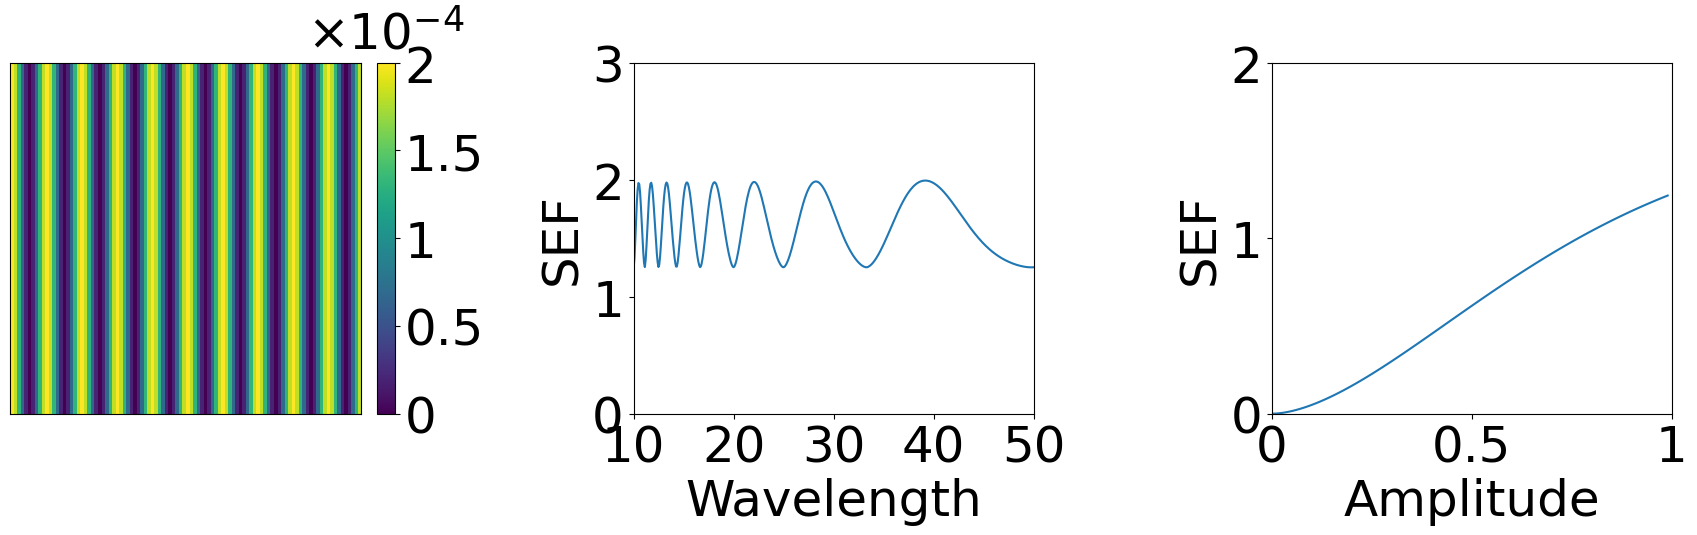

In [ ]:
n = 100
wavelength = 10
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength) # adding the pattern

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
axs[0].set_xticks([])
axs[0].set_yticks([])


pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)

# calculate SEF for wavelength variation
sef_storage = []
for wavelen in np.linspace(10,50,501):
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(np.linspace(10,50,501),sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(10,50)
axs[1].set_xticks([10,20,30,40,50])
axs[1].set_ylim(0,3)

# calculate SEF for amplitude variation
sef_storage_2 = []
for amp in range(0,100):
    pattern = 1 + amp*0.01*np.cos(2 * np.pi * X / wavelength)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)

plt.tight_layout()
plt.savefig('supp_fig_cos')
plt.show()

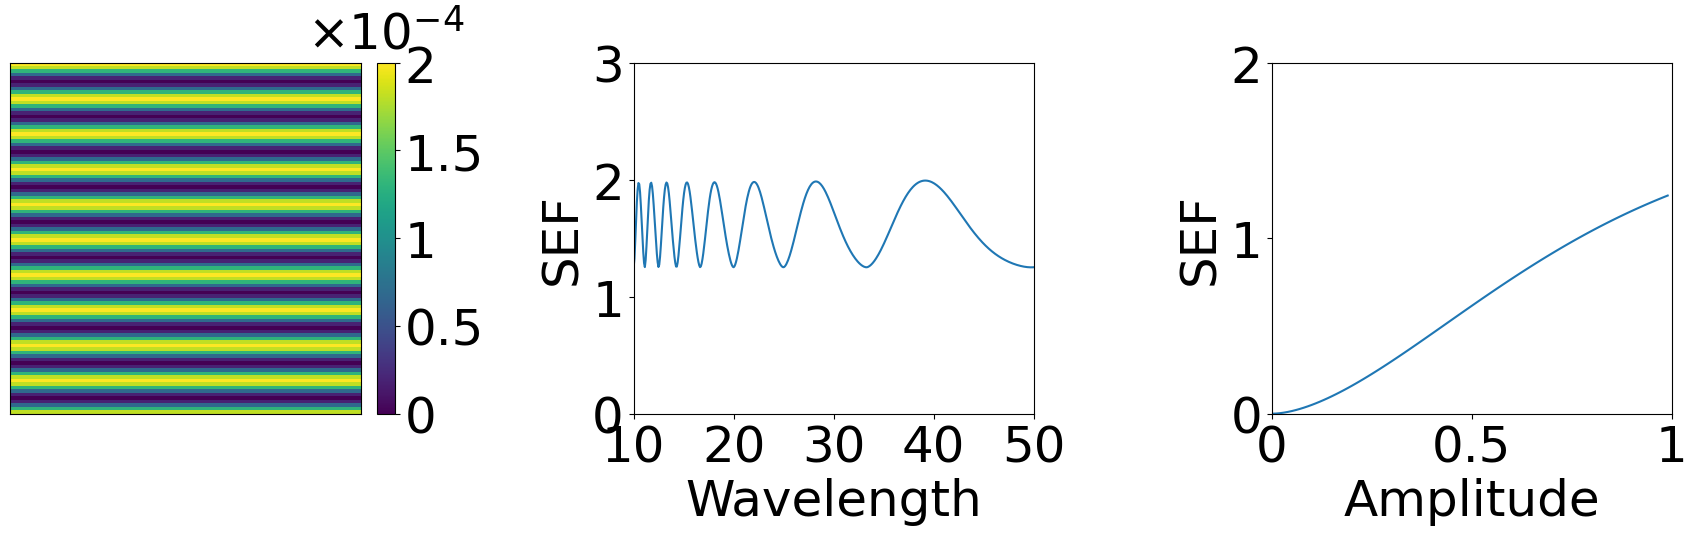

In [ ]:
n = 100
wavelength = 10
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * Y / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
axs[0].set_xticks([])
axs[0].set_yticks([])


pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)




sef_storage = []
for wavelen in np.linspace(10,50,501):
    pattern = 1 + amplitude*np.cos(2 * np.pi * Y / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(np.linspace(10,50,501),sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(10,50)
axs[1].set_xticks([10,20,30,40,50])
axs[1].set_ylim(0,3)


sef_storage_2 = []
for amp in range(0,100):
    pattern = 1 + amp*0.01*np.cos(2 * np.pi * Y / wavelength)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)

plt.tight_layout()

plt.savefig('supp_fig_orient')
plt.show()

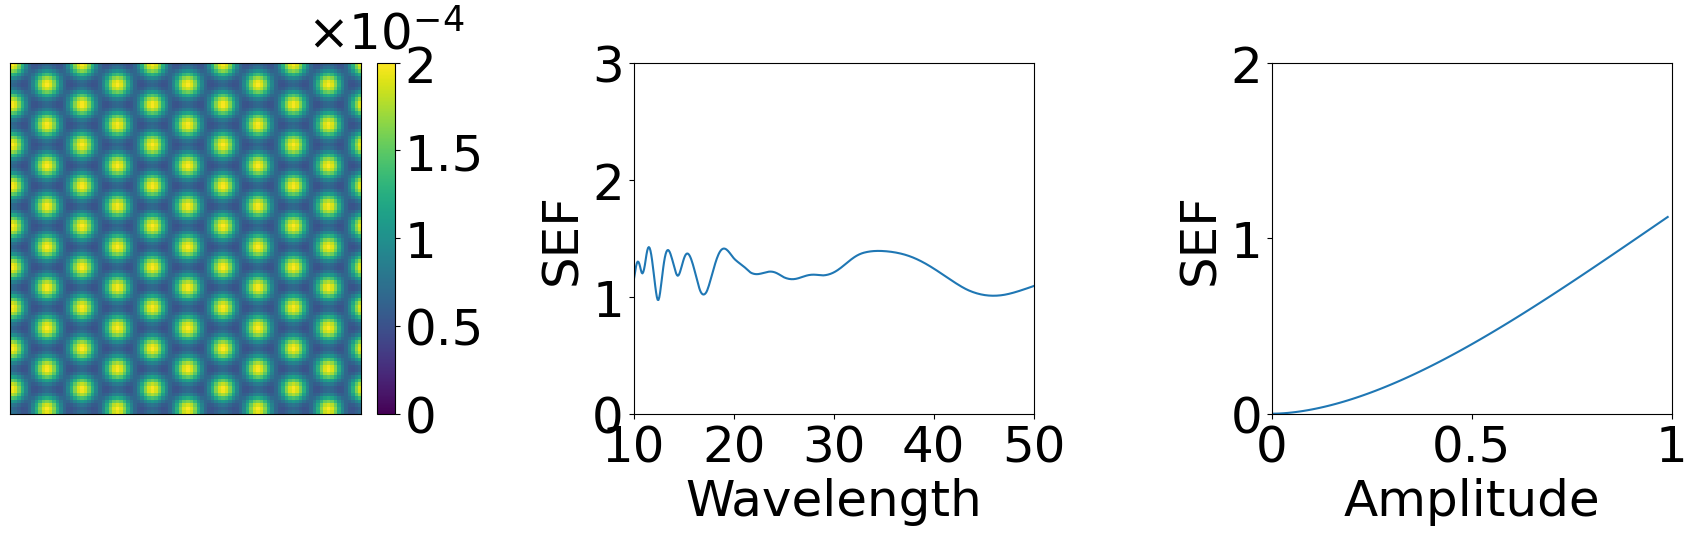

In [ ]:
n = 100
wavelength = 10
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

k = 2 * np.pi / wavelength

pattern = 1 + (
    (amplitude/3)*np.cos(k * X) +
    (amplitude/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amplitude/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y))
)


fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
axs[0].set_xticks([])
axs[0].set_yticks([])

pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)

sef_storage = []
for wavelen in np.linspace(10,50,501):
    k = 2 * np.pi / wavelen
    pattern = 1 + (
    (amplitude/3)*np.cos(k * X) +
    (amplitude/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amplitude/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y)))
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(np.linspace(10,50,501),sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(10,50)
axs[1].set_xticks([10,20,30,40,50])
axs[1].set_ylim(0,3)

sef_storage_2 = []
k = 2 * np.pi / wavelength
for amp in range(0,100):
    pattern = 1 + (
    (amp*0.01/3)*np.cos(k * X) +
    (amp*0.01/3)*np.cos(k * (-0.5*X + np.sqrt(3)/2 * Y)) +
    (amp*0.01/3)*np.cos(k * (-0.5*X - np.sqrt(3)/2 * Y)))
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)

plt.tight_layout()
plt.savefig('supp_fig_spots_half')
plt.show()

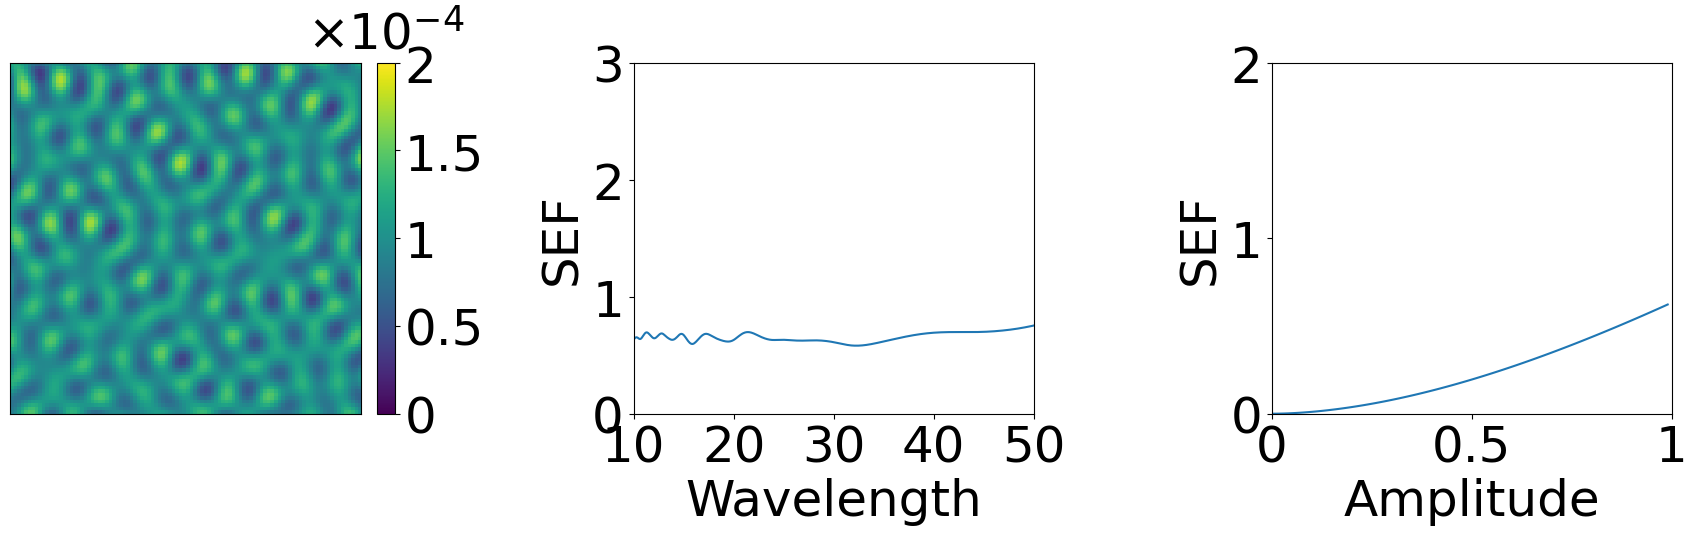

In [ ]:
n = 100
wavelength = 10
k = 2*np.pi / wavelength
N = 9                   # number of modes
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = np.ones((n, n))
np.random.seed(0)
angles = np.random.uniform(0, 2*np.pi, N)
phases = np.random.uniform(0, 2*np.pi, N)

for theta, phi in zip(angles, phases):
    kx = k * np.cos(theta)
    ky = k * np.sin(theta)
    alpha = amplitude / N
    pattern += alpha * np.cos(kx*X + ky*Y + phi)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 3,
    figsize=(18, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,0.5]}
)

fig.subplots_adjust(wspace=0.05)
axs[0].set_xticks([])
axs[0].set_yticks([])
pattern_disp = pattern / np.sum(pattern)
img = axs[0].imshow(pattern_disp, vmin=0, vmax=0.0002)

cbar = plt.colorbar(img, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.00005,0.0001,0.00015,  0.0002])
cbar.set_ticklabels(['0', '0.5', '1', '1.5', '2'])
cbar.ax.set_title(r'$\times 10^{-4}$', fontsize=fon, pad=10)

sef_storage = []
for wavelen in np.linspace(10,50,501):
    pattern = np.ones((n, n))
    k = 2*np.pi / wavelen
    np.random.seed(0)
    angles = np.random.uniform(0, 2*np.pi, N)
    
    for theta in angles:
        kx = k * np.cos(theta)
        ky = k * np.sin(theta)
        alpha = amplitude / N
        pattern += alpha * np.cos(kx*X + ky*Y)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[1].plot(np.linspace(10,50,501),sef_storage)
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("SEF")
axs[1].set_xlim(10,50)
axs[1].set_xticks([10,20,30,40,50])
axs[1].set_ylim(0,3)


sef_storage_2 = []
for amp in range(0,100):
    pattern = np.ones((n, n))
    k = 2*np.pi / wavelength
    np.random.seed(0)
    angles = np.random.uniform(0, 2*np.pi, N)
    
    for theta in angles:
        kx = k * np.cos(theta)
        ky = k * np.sin(theta)
        alpha = amp*0.01 / N
        pattern += alpha * np.cos(kx*X + ky*Y)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    sef_storage_2.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))

axs[2].plot(sef_storage_2)
axs[2].set_xlabel("Amplitude")
axs[2].set_ylabel("SEF")
axs[2].set_xlim(0,100)
axs[2].set_xticks([0,50,100],[0,0.5,1])
axs[2].set_ylim(0,2)

plt.tight_layout()
plt.savefig('supp_fig_labyrinth')
plt.show()

# Supplementary Figure 4A

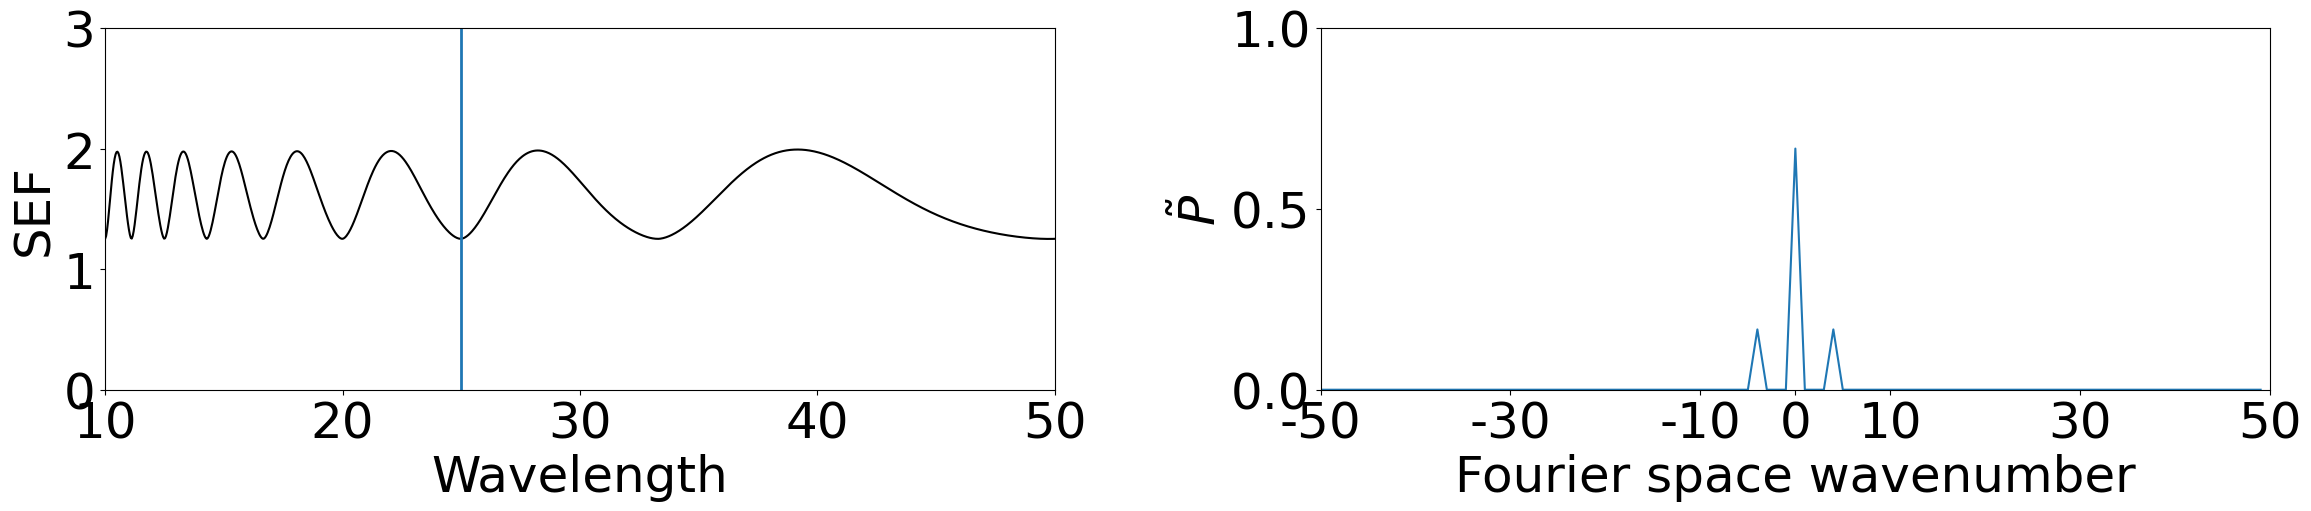

In [ ]:
n = 100
wavelength = 25
amplitude = 1
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)
pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm


wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(25,linewidth = 2)


axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    

plt.tight_layout()
plt.savefig('supp_fig_oscsef_1')
plt.show()

# Supplementary Figure 4B

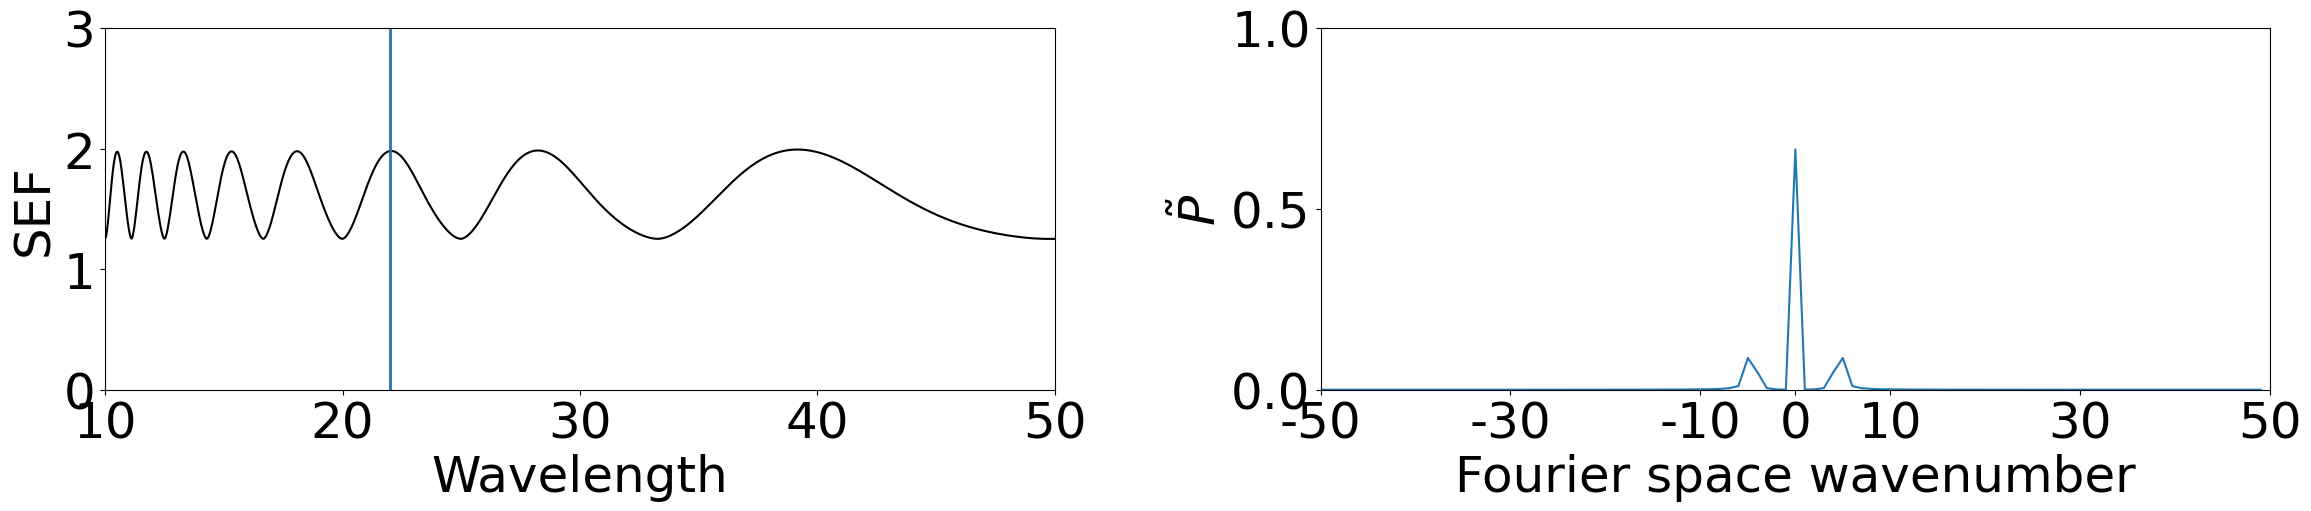

In [ ]:
n = 100
wavelength = 22
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)

pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm

wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(22,linewidth = 2)

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)
    
plt.tight_layout()
plt.savefig('supp_fig_oscsef_2')
plt.show()

# Supplementary Figure 4C

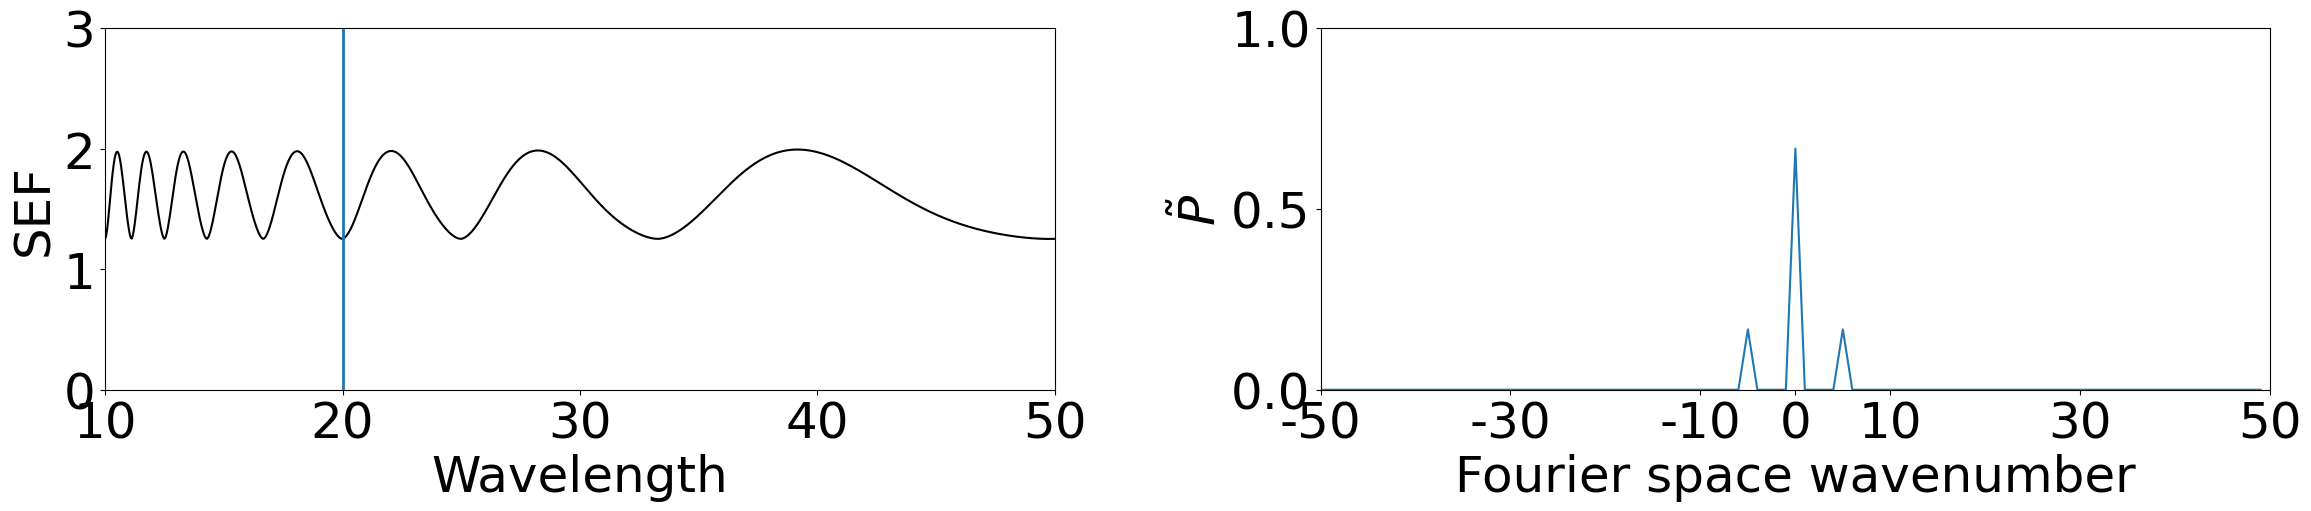

In [ ]:
n = 100
wavelength = 20
amplitude = 1
x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)

pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm
wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(20,linewidth = 2)

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig('supp_fig_oscsef_3')
plt.show()

# Supplementary Figure 4D

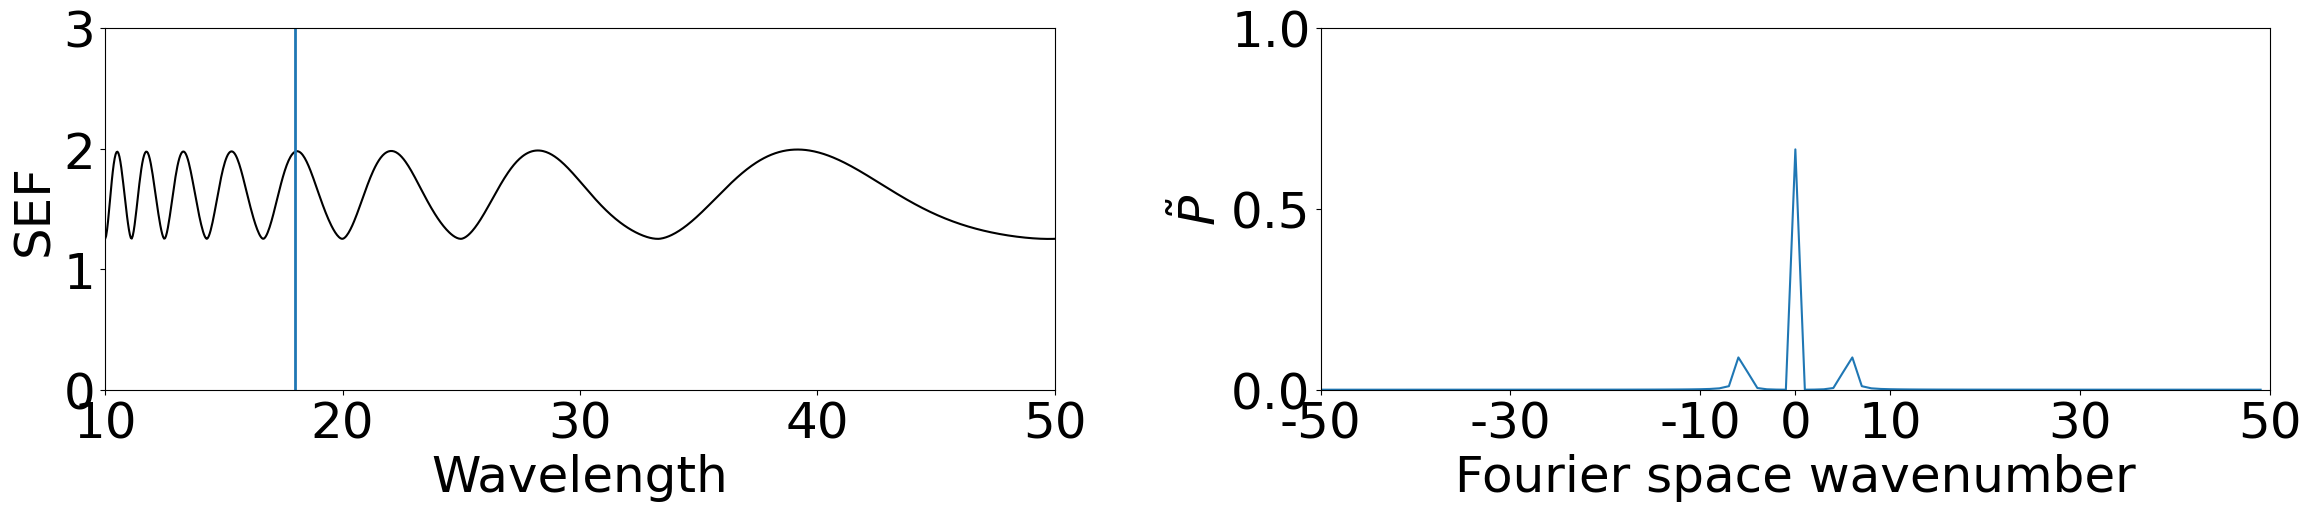

In [ ]:
n = 100
wavelength = 18
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 36
mpl.rcParams['font.size'] = fon

fig, axs = plt.subplots(
    1, 2,
    figsize=(24, 6),
    gridspec_kw={'width_ratios': [0.5, 0.5,]}
)

fig.subplots_adjust(wspace=0.05)

pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm
wav = np.linspace(10,50,1000)

sef_storage = []
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
axs[0].plot(wav,sef_storage,"black")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("SEF")
axs[0].set_xlim(10,50)
axs[0].set_ylim(0,3)
axs[0].axvline(18,linewidth = 2)

axs[1].plot(power_spectrum_norm_disp[50])
axs[1].set_xlabel("Fourier space wavenumber")
axs[1].set_ylabel(r"$\tilde{P}$")
axs[1].set_xlim(0,100)
axs[1].set_xticks([0,20,40,50,60,80,100],[-50,-30,-10,0,10,30,50])
axs[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig('supp_fig_oscsef_4')
plt.show()

# Supplementary Figure 4E

The idea is that if a wavelength can divide the number 100 (size of domain) perfectly, then it results in a relatively lower SEF value. (Theoretically, there are infinite oscillations if you allow wavelengths below 1, but oscillations below a certain wavelengths are effectively meaningless.)

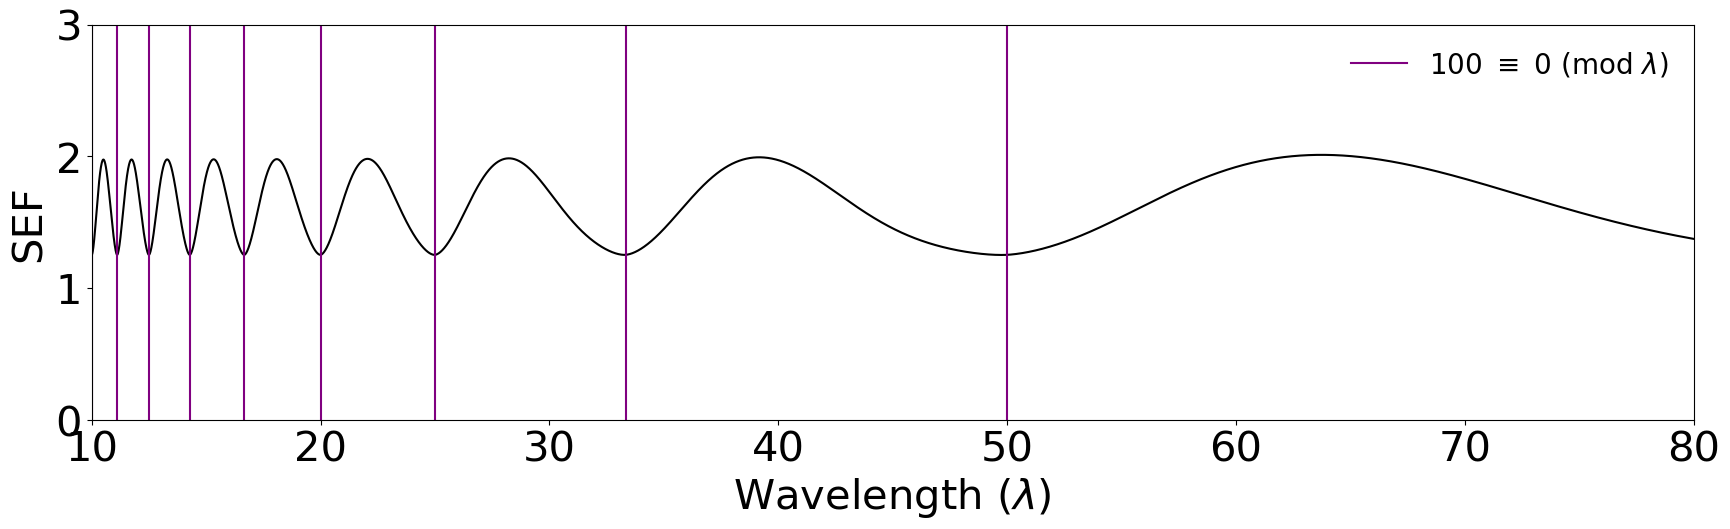

In [ ]:
n = 100
wavelength = 8
amplitude = 1

x = np.arange(n)
y = np.arange(n)
X, Y = np.meshgrid(x, y)

pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelength)

fon = 30
mpl.rcParams['font.size'] = fon

pattern_disp = pattern / np.sum(pattern)
fft_vals = np.fft.fft2(pattern)
fft_shifted = np.fft.fftshift(fft_vals)
power_spectrum = abs(fft_shifted)**2
power_spectrum_norm = power_spectrum/np.sum(power_spectrum)
power_spectrum_norm_disp = power_spectrum_norm

sef_storage = []
wav = np.linspace(10,80,10001)
for wavelen in wav:
    pattern = 1 + amplitude*np.cos(2 * np.pi * X / wavelen)
    fft_vals = np.fft.fft2(pattern)
    fft_shifted = np.fft.fftshift(fft_vals)
    power_spectrum = np.abs(fft_shifted)**2
    power_spectrum_norm = power_spectrum / np.sum(power_spectrum)
    
    sef_storage.append(-np.sum(power_spectrum_norm * np.log2(power_spectrum_norm + 1e-16)))
plt.figure(figsize = (18,6))
plt.plot(wav,sef_storage, color = 'black')
plt.xlabel(r"Wavelength ($\lambda$)")
plt.ylabel("SEF")
plt.xlim(10,80)
plt.ylim(0,3)
for i in range(1,1000):
    plt.axvline(100/i, color = 'purple')
legend_line = Line2D([0], [0], color='purple')
plt.legend([legend_line], [r'100 $\equiv$ 0 (mod $\lambda$)'],fontsize = 20,frameon = False)
plt.tight_layout()
plt.savefig('supp_fig_oscsef_gen')
plt.show()